# OAI Screening Images — Preprocessing (CLAHE → 224×224 PNGs)

Reads the raw bilateral knee DICOMs from Drive, applies the unified preprocessing
pipeline, splits each bilateral X-ray into left/right knee crops, and saves
224×224 grayscale PNGs back to Drive.

**All input and output is on Google Drive — nothing is written to local Colab storage.**

| Path | Role |
|------|------|
| `My Drive/oai/screening_images/` | Input raw DICOMs (already downloaded) |
| `My Drive/oai/oai_labels.csv` | Subject ID / side / KL grade index |
| `My Drive/oai/processed/` | Output 224×224 PNGs |
| `My Drive/oai/oai_processed_labels.csv` | Final labels CSV with filenames |

### Pipeline per DICOM
```
Load DICOM → RescaleSlope/Intercept → MONOCHROME1 invert → percentile-1/99 → uint8
  → split bilateral (left half = R knee, right half = L knee)
  → flip L crop for consistent orientation
  → CLAHE(clip=2.0, tile=8×8)
  → resize 224×224 LANCZOS
  → save PNG to Drive
```

### Output filenames
```
OAI_9000296_R_clahe-2.0_224px.png
OAI_9000296_L_clahe-2.0_224px.png
```

### Checkpoint
A `checkpoint.json` is written to Drive after every image — safe to interrupt and resume at any time.

In [9]:

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [10]:

import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '--quiet',
    'pydicom', 'opencv-python-headless', 'Pillow', 'numpy', 'pandas', 'tqdm'
])
print('Packages ready.')

Packages ready.


In [11]:

import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from tqdm.notebook import tqdm

DRIVE_ROOT = Path('/content/drive/MyDrive')
PROJECT    = DRIVE_ROOT / 'Master Thesis'

IMAGE_DIR      = PROJECT / 'oai' / 'screening_images'
LABELS_CSV     = PROJECT / 'oai' / 'oai_labels.csv'
OUT_DIR        = PROJECT / 'oai' / 'processed'
OUT_LABELS_CSV = PROJECT / 'oai' / 'oai_processed_labels.csv'
CHECKPOINT     = OUT_DIR / 'checkpoint.json'

IMG_SIZE    = 224
CLAHE_CLIP  = 2.0
CLAHE_TILE  = (8, 8)
PNG_SUFFIX  = 'clahe-2.0_224px'

FORCE_FRESH = True

OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration:')
for name, p in [
    ('PROJECT',    PROJECT),
    ('IMAGE_DIR',  IMAGE_DIR),
    ('LABELS_CSV', LABELS_CSV),
    ('OUT_DIR',    OUT_DIR),
]:
    status = '✅' if p.exists() else '❌ NOT FOUND'
    print(f'  {status}  {name}: {p}')
print(f'\nFORCE_FRESH = {FORCE_FRESH}')


Configuration:
  ✅  PROJECT: /content/drive/MyDrive/Master Thesis
  ✅  IMAGE_DIR: /content/drive/MyDrive/Master Thesis/oai/screening_images
  ✅  LABELS_CSV: /content/drive/MyDrive/Master Thesis/oai/oai_labels.csv
  ✅  OUT_DIR: /content/drive/MyDrive/Master Thesis/oai/processed

FORCE_FRESH = True


In [12]:


if not LABELS_CSV.exists():
    raise FileNotFoundError(
        f'Labels CSV not found: {LABELS_CSV}\n'
        'Run oai_labels.ipynb first to generate oai_labels.csv.'
    )

labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
labels['subject_id'] = labels['subject_id'].str.strip()

print(f'Label rows loaded  : {len(labels):,}')
print(f'Unique subjects    : {labels["subject_id"].nunique():,}')
print('KL distribution:')
print(labels['kl_grade'].value_counts().sort_index())

Label rows loaded  : 8,921
Unique subjects    : 4,490
KL distribution:
kl_grade
0    3440
1    1588
2    2362
3    1237
4     294
Name: count, dtype: int64


In [13]:


print('Scanning for DICOMs on Drive (this may take a minute) ...')

subject_dicoms: dict[str, dict[str, Path]] = {}
for p in IMAGE_DIR.rglob('*'):
    if p.is_file() and p.suffix == '':
        parts = p.relative_to(IMAGE_DIR).parts
        if len(parts) >= 2:
            series, subject = parts[0], parts[1]
            subject_dicoms.setdefault(subject, {})[series] = p

PREFERRED_SERIES = '0.C.2'

def best_dicom(subject: str) -> Path | None:
    """Return the preferred DICOM path for a subject."""
    series_map = subject_dicoms.get(subject, {})
    if not series_map:
        return None
    return series_map.get(PREFERRED_SERIES) or next(iter(series_map.values()))

label_subjects = set(labels['subject_id'])
image_subjects = set(subject_dicoms.keys())
matched        = label_subjects & image_subjects

print(f'DICOMs on Drive    : {sum(len(v) for v in subject_dicoms.values()):,} files')
print(f'Unique subjects    : {len(image_subjects):,}')
print(f'Label subjects     : {len(label_subjects):,}')
print(f'Matched (both)     : {len(matched):,}')
print(f'Labels w/o DICOM   : {len(label_subjects - image_subjects):,}')
print(f'DICOMs w/o label   : {len(image_subjects - label_subjects):,}')

labels_matched = labels[labels['subject_id'].isin(matched)].reset_index(drop=True)
print(f'\nKnee rows to process: {len(labels_matched):,}')

Scanning for DICOMs on Drive (this may take a minute) ...
DICOMs on Drive    : 4,795 files
Unique subjects    : 4,795
Label subjects     : 4,490
Matched (both)     : 4,490
Labels w/o DICOM   : 0
DICOMs w/o label   : 305

Knee rows to process: 8,921


In [14]:


clahe_proc = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)

def load_dicom_array(path: Path) -> np.ndarray:
    """Load DICOM → normalised uint8 (percentile 1-99 stretch)."""
    ds  = pydicom.dcmread(str(path))
    arr = ds.pixel_array.astype(np.float32)

    slope     = float(getattr(ds, 'RescaleSlope', 1))
    intercept = float(getattr(ds, 'RescaleIntercept', 0))
    arr = arr * slope + intercept

    photometric = getattr(ds, 'PhotometricInterpretation', 'MONOCHROME2')
    if photometric == 'MONOCHROME1':
        arr = arr.max() - arr

    lo, hi = float(np.percentile(arr, 1)), float(np.percentile(arr, 99))
    if hi - lo < 1:
        lo, hi = float(arr.min()), float(arr.max())
    if hi - lo < 1:
        return np.zeros(arr.shape, dtype=np.uint8)
    arr = np.clip((arr - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    return arr

def split_bilateral(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Split bilateral X-ray at horizontal midpoint.

    In a PA view (patient facing detector):
      - Image LEFT  half  → patient's RIGHT knee
      - Image RIGHT half  → patient's LEFT knee (mirrored for consistent orientation)
    Returns: (right_crop, left_crop) both in standard orientation.
    """
    mid         = arr.shape[1] // 2
    right_crop  = arr[:, :mid]
    left_crop   = np.fliplr(arr[:, mid:])
    return right_crop, left_crop

def apply_clahe_resize(crop: np.ndarray) -> np.ndarray:
    """CLAHE then resize to IMG_SIZE × IMG_SIZE."""
    enhanced = clahe_proc.apply(crop)
    resized  = Image.fromarray(enhanced, 'L').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.array(resized)

print('Pipeline functions defined.')

Pipeline functions defined.


In [15]:


def load_checkpoint() -> set:
    if CHECKPOINT.exists():
        try:
            return set(json.loads(CHECKPOINT.read_text()))
        except (json.JSONDecodeError, OSError):
            pass
    return set()

def save_checkpoint(done: set) -> None:
    CHECKPOINT.write_text(json.dumps(sorted(done), indent=2))

if FORCE_FRESH:
    already_done = set()
    print('FORCE_FRESH=True — starting from scratch, all knees will be reprocessed.')
else:
    already_done = load_checkpoint()
    print(f'Resuming from checkpoint: {len(already_done):,} knees already done.')

todo_rows = labels_matched[
    ~labels_matched.apply(
        lambda r: f"{r['subject_id']}_{r['side']}" in already_done, axis=1
    )
].reset_index(drop=True)

print(f'Total knee rows    : {len(labels_matched):,}')
print(f'Already processed  : {len(already_done):,}')
print(f'Remaining          : {len(todo_rows):,}')


FORCE_FRESH=True — starting from scratch, all knees will be reprocessed.
Total knee rows    : 8,921
Already processed  : 0
Remaining          : 8,921


---
## Main Processing Loop

Reads each DICOM from Drive, splits into L/R crops, applies CLAHE + resize, saves two PNGs back to Drive.

- **Safe to interrupt** — checkpoint is written after every knee pair. Re-run this cell to resume.
- **Expected time** — ~3–6 hours for ~4,700 subjects depending on Drive I/O speed.

In [16]:


import datetime

done_set   = already_done.copy()
errors     = {}
run_start  = datetime.datetime.now()

grouped = todo_rows.groupby('subject_id')

try:
    for subject_id, group in tqdm(grouped, desc='Subjects', unit='subj'):
        dicom_path = best_dicom(subject_id)
        if dicom_path is None:
            for _, row in group.iterrows():
                errors[f"{subject_id}_{row['side']}"] = 'no DICOM found'
            continue

        try:
            full_arr = load_dicom_array(dicom_path)
        except Exception as e:
            for _, row in group.iterrows():
                errors[f"{subject_id}_{row['side']}"] = f'dicom_load: {e}'
            continue

        right_crop, left_crop = split_bilateral(full_arr)
        crops = {'R': right_crop, 'L': left_crop}

        for _, row in group.iterrows():
            side  = row['side']
            key   = f'{subject_id}_{side}'
            fname = f'OAI_{subject_id}_{side}_{PNG_SUFFIX}.png'
            out   = OUT_DIR / fname

            if out.exists() and not FORCE_FRESH:
                done_set.add(key)
                save_checkpoint(done_set)
                continue

            try:
                processed = apply_clahe_resize(crops[side])
                Image.fromarray(processed, 'L').save(str(out))
                done_set.add(key)
                save_checkpoint(done_set)
            except Exception as e:
                errors[key] = f'process: {e}'

except KeyboardInterrupt:
    print('\nInterrupted. Progress saved — re-run this cell to resume.')

if errors:
    error_log = OUT_DIR / 'errors.log'
    with open(error_log, 'a') as f:
        for k, msg in errors.items():
            f.write(f'{k}\t{msg}\n')
    print(f'{len(errors)} error(s) logged to {error_log}')

elapsed = datetime.datetime.now() - run_start
print(f'\nRun started      : {run_start.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Elapsed          : {str(elapsed).split(".")[0]}')
print(f'Done this run    : {len(done_set) - len(already_done):,}')
print(f'Total completed  : {len(done_set):,} / {len(labels_matched):,} knees')
print(f'Errors           : {len(errors)}')


Subjects:   0%|          | 0/4490 [00:00<?, ?subj/s]

/tmp/ipykernel_1167/2210312591.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  resized  = Image.fromarray(enhanced, 'L').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
/usr/local/lib/python3.12/dist-packages/pydicom/charset.py:727: UserWarning: Incorrect value for Specific Character Set 'ISO_2022_IR_6' - assuming 'ISO 2022 IR 6'
  _warn_about_invalid_encoding(encoding, patched)


374 error(s) logged to /content/drive/MyDrive/Master Thesis/oai/processed/errors.log

Run started      : 2026-05-28 07:33:07
Elapsed          : 1:27:06
Done this run    : 8,547
Total completed  : 8,547 / 8,921 knees
Errors           : 374


In [17]:


pngs = list(OUT_DIR.glob('OAI_*_*_*.png'))
print(f'PNGs found in {OUT_DIR}: {len(pngs):,}')

rows = []
for p in pngs:

    parts = p.stem.split('_')
    if len(parts) < 3:
        continue
    sid  = parts[1]
    side = parts[2]
    rows.append({'filename': p.name, 'subject_id': sid, 'side': side})

proc_df = pd.DataFrame(rows)

proc_df = proc_df.merge(
    labels[['subject_id', 'side', 'kl_grade']],
    on=['subject_id', 'side'],
    how='left'
)

missing_kl = proc_df['kl_grade'].isna().sum()
if missing_kl > 0:
    print(f'WARNING: {missing_kl} PNGs have no matching KL grade — they will be excluded.')
    proc_df = proc_df.dropna(subset=['kl_grade'])

proc_df['kl_grade'] = proc_df['kl_grade'].astype(int)
proc_df = proc_df.sort_values(['subject_id', 'side']).reset_index(drop=True)

proc_df.to_csv(OUT_LABELS_CSV, index=False)
print(f'\nSaved: {OUT_LABELS_CSV}  ({len(proc_df):,} rows)')
print('\nKL distribution in processed dataset:')
print(proc_df['kl_grade'].value_counts().sort_index())
print('\nSample rows:')
print(proc_df.head(6).to_string(index=False))

PNGs found in /content/drive/MyDrive/Master Thesis/oai/processed: 8,547

Saved: /content/drive/MyDrive/Master Thesis/oai/oai_processed_labels.csv  (8,547 rows)

KL distribution in processed dataset:
kl_grade
0    3326
1    1523
2    2241
3    1178
4     279
Name: count, dtype: int64

Sample rows:
                         filename subject_id side  kl_grade
OAI_9000099_L_clahe-2.0_224px.png    9000099    L         3
OAI_9000099_R_clahe-2.0_224px.png    9000099    R         2
OAI_9000296_L_clahe-2.0_224px.png    9000296    L         3
OAI_9000296_R_clahe-2.0_224px.png    9000296    R         2
OAI_9000622_L_clahe-2.0_224px.png    9000622    L         1
OAI_9000622_R_clahe-2.0_224px.png    9000622    R         1


In [18]:

import shutil

pngs_all = list(OUT_DIR.glob('OAI_*.png'))
total_mb = sum(p.stat().st_size for p in pngs_all) / 1e6

print('=== OAI Processed Output ===')
print(f'Processed PNGs     : {len(pngs_all):,}')
print(f'Total on Drive     : {total_mb:.1f} MB  ({total_mb/1e3:.2f} GB)')

if pngs_all:
    sizes = [p.stat().st_size / 1e3 for p in pngs_all]
    print(f'File size range    : {min(sizes):.1f} – {max(sizes):.1f} KB')
    print(f'Mean file size     : {sum(sizes)/len(sizes):.1f} KB')

    sample = pngs_all[0]
    img = Image.open(str(sample))
    print(f'\nSpot-check: {sample.name}')
    print(f'  Size    : {img.size}')
    print(f'  Mode    : {img.mode}')
    arr = np.array(img)
    print(f'  Min/Max : {arr.min()} / {arr.max()}')
    print(f'  Mean    : {arr.mean():.1f}')

expected = len(proc_df)
if len(pngs_all) >= expected:
    print(f'\n✅ All {expected:,} expected PNGs present.')
else:
    missing = expected - len(pngs_all)
    print(f'\n⚠ {missing:,} PNGs missing — re-run Cell 8 to complete.')

_, _, free = shutil.disk_usage('/content/drive/MyDrive')
print(f'\nDrive free         : {free/1e9:.1f} GB')

=== OAI Processed Output ===
Processed PNGs     : 8,547
Total on Drive     : 200.4 MB  (0.20 GB)
File size range    : 12.5 – 30.4 KB
Mean file size     : 23.4 KB

Spot-check: OAI_9000099_L_clahe-2.0_224px.png
  Size    : (224, 224)
  Mode    : L
  Min/Max : 0 / 255
  Mean    : 119.7

✅ All 8,547 expected PNGs present.

Drive free         : 72.2 GB


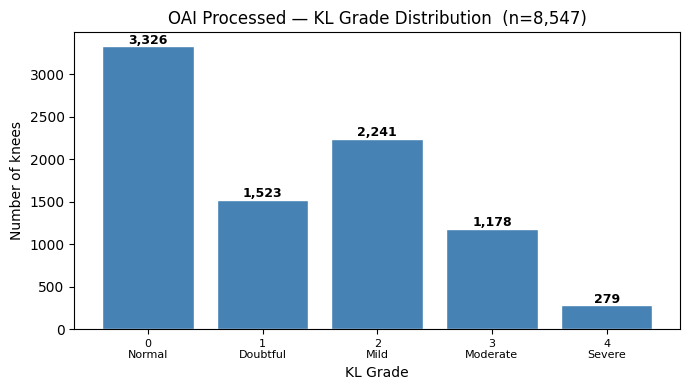

Plot saved: /content/drive/MyDrive/Master Thesis/oai/oai_processed_kl_distribution.png


In [19]:

import matplotlib.pyplot as plt

counts = proc_df['kl_grade'].value_counts().sort_index()
kl_names = ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('KL Grade')
ax.set_ylabel('Number of knees')
ax.set_title(f'OAI Processed — KL Grade Distribution  (n={len(proc_df):,})')
ax.set_xticks(range(5))
ax.set_xticklabels([f'{i}\n{kl_names[i]}' for i in range(5)], fontsize=8)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plot_path = PROJECT / 'oai' / 'oai_processed_kl_distribution.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Plot saved: {plot_path}')


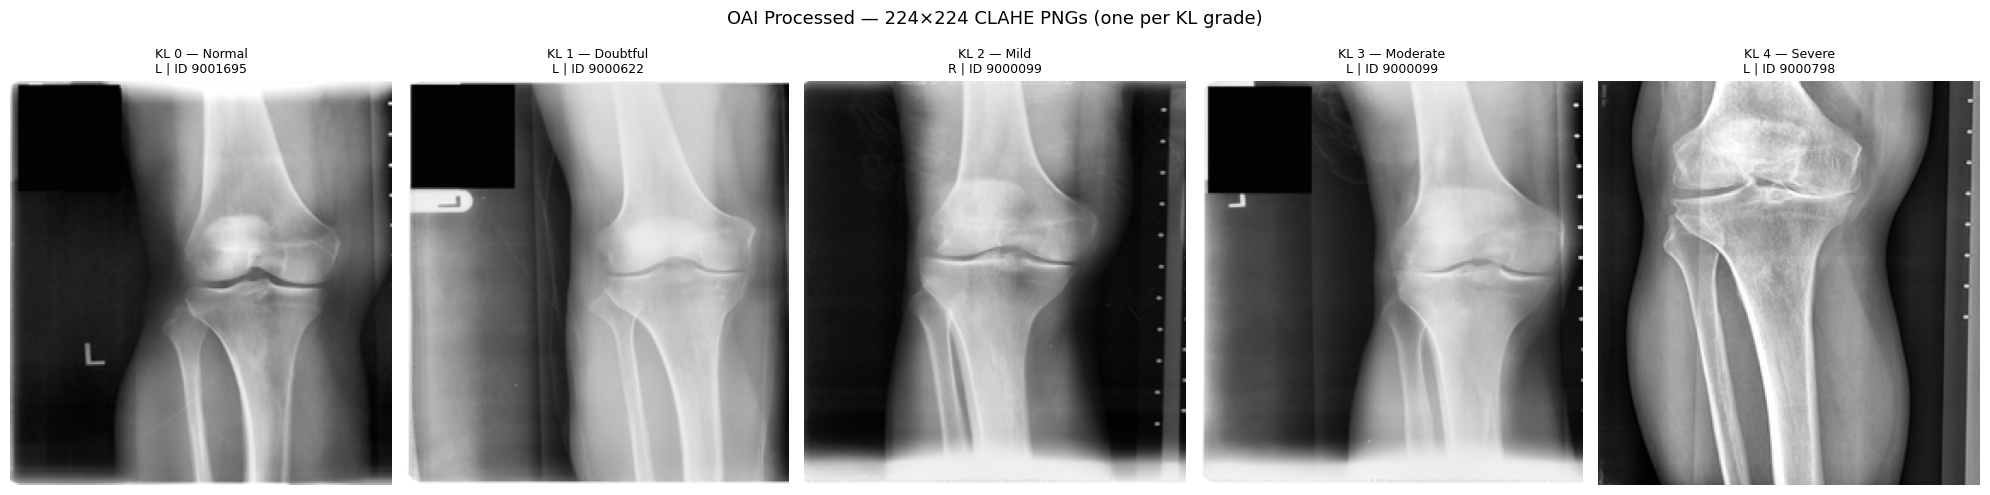

Saved: /content/drive/MyDrive/Master Thesis/oai/oai_processed_samples.png


In [20]:


fig, axes = plt.subplots(1, 5, figsize=(20, 5))
kl_names  = ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']

for ax, kl in zip(axes, range(5)):
    subset = proc_df[proc_df['kl_grade'] == kl]
    if len(subset) == 0:
        ax.text(0.5, 0.5, f'KL {kl}\nNo sample', ha='center', va='center')
        ax.axis('off')
        continue
    row   = subset.iloc[0]
    fpath = OUT_DIR / row['filename']
    try:
        img = np.array(Image.open(str(fpath)).convert('L'))
        ax.imshow(img, cmap='gray', aspect='auto')
        ax.set_title(
            f'KL {kl} — {kl_names[kl]}\n{row["side"]} | ID {row["subject_id"]}',
            fontsize=9
        )
    except Exception as e:
        ax.text(0.5, 0.5, f'Error\n{e}', ha='center', va='center', fontsize=8)
    ax.axis('off')

fig.suptitle('OAI Processed — 224×224 CLAHE PNGs (one per KL grade)', fontsize=13)
plt.tight_layout()
sample_path = PROJECT / 'oai' / 'oai_processed_samples.png'
plt.savefig(sample_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {sample_path}')
